# 9 · Optimized kernels, dispatch, and operator fusion

The first eight tutorials are about *expressing* mathematics. This one is about the
layers that make that mathematics run fast **without changing how you write
it** — and that all stay out of your way until you ask for them:

* **Optimized-kernel dispatch** ([ADR-016](../../docs/dev/adr/016_kernel_layers.md)) —
  route an operation to the most efficient *bit-exact* array implementation
  (one batched ``matmul`` instead of a per-block loop, for example). It is
  **off by default**: your results never change, and a fast path is taken only
  when you opt in *and* it is provably equivalent.
* **Lazy operator algebra and fusion** ([ADR-021](../../docs/dev/adr/021_lazy_operator_algebra_and_simplification.md)) —
  simplify an *operator expression* and *multiply operators together where
  possible* (collapse ``A @ B @ C`` of dense operators into one matrix). Cheap
  rewrites happen automatically at construction; materializing fusions are an
  **explicit** ``fuse()`` call.
* **Caching the materialized form** ([ADR-022](../../docs/dev/adr/022_caching.md)) —
  when a fold has to build an array from its operands (stacking ``K`` blocks for one
  batched ``matmul``), build it **once and reuse it** across applies instead of
  rebuilding every call.

None of these touch the matrix-free contract: a matrix-free operator is never
silently turned into a dense one.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import spacecore as sc

BLUE, INDIGO, CYAN, SLATE = "#2563eb", "#4338ca", "#0891b2", "#475569"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)
rng = np.random.default_rng(0)

## 1 · Two kernel layers

`spacecore.kernels` keeps optimization logic out of the operator classes and
splits it in two:

* **Core kernels** are the check-free bodies of ``apply``/``rapply``/… They are
  bound to each operator *once*, at class-definition time, and are **always on
  the default path** — there is nothing to enable.
* **Benchmarked specs** are heavier fast paths (a batched ``matmul`` over uniform
  dense blocks, an algebraic short-circuit) described by a ``KernelSpec``. They
  are **routed by a single dispatcher**, and dispatch is **off by default**.

Let's build an operator the dispatcher knows a fast path for: a block-diagonal
operator whose blocks are all the same-shape dense matrices.

In [2]:
n, K = 6, 4
X = sc.DenseCoordinateSpace((n,), ctx)
block_mats = [rng.standard_normal((n, n)) for _ in range(K)]
blocks = tuple(sc.DenseLinOp(ctx.asarray(M), X, X, ctx) for M in block_mats)

A = sc.BlockDiagonalLinOp.from_operators(blocks)   # K independent dense blocks
x = tuple(ctx.asarray(rng.standard_normal(n)) for _ in range(K))   # a tree element is just a tuple

y = A.apply(x)            # the default path (core kernel: a per-block loop)
print("blocks      :", K, "x", (n, n))
print("output parts:", [tuple(np.asarray(yi).shape) for yi in y])

blocks      : 4 x (6, 6)
output parts: [(6,), (6,), (6,), (6,)]


### Turning dispatch on

The dispatcher has three modes, set process-globally or — better — for an
enclosing scope with the ``dispatch_mode`` context manager:

* ``"off"`` (default) — always run the plain inline path.
* ``"on"`` — route to the applicable optimized spec (here: stack the blocks and
  issue **one** batched ``matmul`` instead of ``K``).
* ``"verify"`` — run *both* the optimized and the inline path and assert they
  agree bit-for-bit, raising on any mismatch. This is the safety net you run in
  tests/CI before trusting a key.

Because every auto-routable spec is required to be **exactly** equivalent
(``rtol == atol == 0``), ``"on"`` is bit-identical to ``"off"`` — it is faster,
not different.

In [3]:
from spacecore.kernels import dispatch_mode

y_off = A.apply(x)                       # default
with dispatch_mode("on"):
    y_on = A.apply(x)                    # routed to the batched-matmul spec
with dispatch_mode("verify"):
    y_ver = A.apply(x)                   # runs both, asserts agreement

exact = all(np.array_equal(np.asarray(a), np.asarray(b)) for a, b in zip(y_off, y_on))
print("on  is bit-exact to off :", exact)
print("verify mode agreed      :", y_ver is not None)

on  is bit-exact to off : True
verify mode agreed      : True


### Why off by default — the rails

Routing to a fast path is only safe behind a set of rails, all enforced by the
``KernelSpec`` contract:

* **Exactness** — only specs with ``rtol == atol == 0`` are auto-routed.
* **A memory gate** — a *materializing* fast path (one that allocates extra, like
  stacking ``K`` block matrices) carries a shape-only cost estimate, and the
  dispatcher selects it only when that estimate fits the backend's free-memory
  budget. *No estimate, no fuse; no budget, no fuse.*
* **Matrix-free safety** — a matrix-free operator is never silently materialized.

Each operation family the dispatcher knows about is a **dispatch key**; many
specs can register under one key, and the dispatcher picks the highest-priority
applicable one. Here is the live catalog:

In [4]:
from spacecore.kernels import registry

for key in sorted(registry.dispatch_keys()):
    names = [s.name for s in registry.dispatch_candidates(key)]
    print(f"{key:34s} -> {', '.join(names)}")

linop.block_diagonal.apply         -> block-diagonal-uniform-dense-batched
linop.block_diagonal.rapply        -> block-diagonal-uniform-dense-batched-rapply
linop.block_diagonal.rvapply       -> block-diagonal-uniform-dense-batched-rvapply
linop.block_diagonal.vapply        -> block-diagonal-uniform-dense-batched-vapply
linop.composed.apply               -> composed-zero-annihilation, composed-identity-elision
linop.stacked.apply                -> stacked-uniform-dense-batched-apply
linop.sum_to_single.rapply         -> sum-to-single-uniform-dense-batched-rapply


The block-diagonal heatmap below is the structure the fast path exploits: ``K``
independent dense blocks on the diagonal, all the same shape, are exactly the
case a single batched ``matmul`` handles in one backend call.

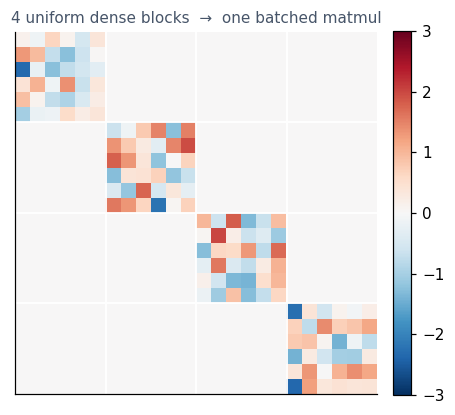

In [5]:
dense_blockdiag = block_diag(*block_mats)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
im = ax.imshow(dense_blockdiag, cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_title(f"{K} uniform dense blocks  →  one batched matmul", fontsize=10, color=SLATE)
for i in range(1, K):
    ax.axhline(i * n - 0.5, color="white", lw=1.2)
    ax.axvline(i * n - 0.5, color="white", lw=1.2)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 2 · Lazy operator algebra and `fuse()`

Operator expressions are **lazy**: ``A @ B``, ``A + B``, ``c * A``, ``A.H`` build
a small tree, evaluating nothing until you apply it. Simplification has two tiers.

**Tier 1 — automatic, at construction.** Cheap, local rewrites happen the moment
you build the expression: an identity factor disappears, a zero map collapses the
product, nested scalars fold. These cost nothing and are always applied.

In [6]:
M1 = sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
I  = sc.IdentityLinOp(X, ctx)

print("M1 @ I  is  M1 :", (M1 @ I) is M1)          # identity elided at construction
print("type of 2*(3*M1):", type(2.0 * (3.0 * M1)).__name__,
      "-> one ScaledLinOp with scalar", (2.0 * (3.0 * M1)).scalar)

M1 @ I  is  M1 : True
type of 2*(3*M1): ScaledLinOp -> one ScaledLinOp with scalar 6.0


**Tier 2 — explicit, with `fuse()`.** *Multiplying operators together* is a
materializing rewrite, so it is something you ask for. ``fuse()`` collapses each
maximal run of dense operators into a single ``DenseLinOp`` holding the matrix
product — the whole chain becomes one matrix.

Fusing reassociates the arithmetic (a matrix product, then apply, differs at the
last bit from applying in sequence), so the result is equal **up to rounding**,
not bit-for-bit. It is adjoint-consistent on any geometry — including
non-Euclidean — because the shared middle-space Riesz maps cancel.

In [7]:
M2 = sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
M3 = sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)

expr  = M1 @ M2 @ M3                 # a lazy composition tree
fused = expr.fuse()                  # one DenseLinOp: M1 @ M2 @ M3 as a single matrix

xv = ctx.asarray(rng.standard_normal(n))
print("before fuse :", type(expr).__name__)
print("after  fuse :", type(fused).__name__)
print("same action :", np.allclose(np.asarray(fused.apply(xv)), np.asarray(expr.apply(xv))))

before fuse : ComposedLinOp
after  fuse : DenseLinOp
same action : True


### The matrix-free rail

``fuse()`` only multiplies operators that already hold a cheap matrix. A
**matrix-free** operator — defined by callables, with no stored matrix — is left
untouched: it stays a lazy leaf and simply breaks the fusible run, so its
matrix-free contract is preserved.

If you genuinely want to densify a matrix-free operand — accepting the cost and
giving up the matrix-free property — that is an **explicit opt-in**:
``fuse(materialize=True)``.

In [8]:
Mf = sc.MatrixFreeLinOp(lambda v: 2.0 * v, lambda v: 2.0 * v, X, X, ctx)  # matrix-free

print("(M1 @ Mf).fuse()                 ->", type((M1 @ Mf).fuse()).__name__,
      " (matrix-free kept lazy)")
print("(M1 @ Mf).fuse(materialize=True) ->", type((M1 @ Mf).fuse(materialize=True)).__name__,
      " (explicitly densified)")

(M1 @ Mf).fuse()                 -> ComposedLinOp  (matrix-free kept lazy)
(M1 @ Mf).fuse(materialize=True) -> DenseLinOp  (explicitly densified)


## 3 · How the two layers compose

Fusion changes *what an operator is*; dispatch reads that structure the next time
you apply. So they cooperate: fusing a block whose definition was a composition of
dense operators turns it into a single dense block — which then makes the
enclosing block-diagonal operator eligible for the batched-``matmul`` fast path.

In [9]:
# A block-diagonal whose blocks are themselves compositions of dense operators.
composed_blocks = tuple(
    sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
    @ sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
    for _ in range(K)
)
B = sc.BlockDiagonalLinOp.from_operators(composed_blocks)
B_fused = B.fuse()                  # each block collapses to one DenseLinOp

print("block type before fuse:", type(B.parts[0]).__name__)
print("block type after  fuse:", type(B_fused.parts[0]).__name__,
      "(now foldable by the block-diagonal dispatch spec)")
print("same action           :",
      all(np.allclose(np.asarray(a), np.asarray(b))
          for a, b in zip(B.apply(x), B_fused.apply(x))))

block type before fuse: ComposedLinOp
block type after  fuse: DenseLinOp (now foldable by the block-diagonal dispatch spec)
same action           : True


## 4 · The performance payoff

The sections above showed the two layers are *correct*. Here is *why you reach
for them* — measured on this machine, on the NumPy backend.

In [10]:
import timeit

def per_apply_us(fn, number=200, repeat=9):
    """Robust per-apply time in microseconds.

    Each of ``repeat`` batches times ``number`` back-to-back calls (so per-call
    jitter averages out within a batch); we report the **median** across batches,
    which rejects the occasional outlier from GC or a busy core far better than a
    single timed run. Result is microseconds per one ``apply``.
    """
    fn()                                    # warm up (allocator, caches, any JIT)
    batches = timeit.repeat(fn, number=number, repeat=repeat)
    return float(np.median(batches)) / number * 1e6

n_big, depth = 384, 16
Xb = sc.DenseCoordinateSpace((n_big,), ctx)
factors = [sc.DenseLinOp(ctx.asarray(rng.standard_normal((n_big, n_big))), Xb, Xb, ctx)
           for _ in range(depth)]
chain = factors[0]
for f in factors[1:]:
    chain = chain @ f                       # a lazy depth-16 composition
fused = chain.fuse()                        # one DenseLinOp: the product matrix
xb = ctx.asarray(rng.standard_normal(n_big))

t_lazy  = per_apply_us(lambda: chain.apply(xb))
t_fused = per_apply_us(lambda: fused.apply(xb))
print(f"lazy chain (depth {depth}) : {t_lazy:7.1f} us / apply   ({depth} matvecs)")
print(f"fused (one matmul)      : {t_fused:7.1f} us / apply   (1 matvec)")
print(f"speedup per apply       : {t_lazy / t_fused:5.1f}x")

lazy chain (depth 16) :   211.4 us / apply   (16 matvecs)
fused (one matmul)      :    19.6 us / apply   (1 matvec)
speedup per apply       :  10.8x


**Fusion amortizes a deep composition.** Applying the lazy chain walks every
factor on *every* call — ``depth`` matrix–vector products. ``fuse()`` precomputes
the single product matrix once, so each later apply is **one** matvec. The
wall-clock gain tracks that ``depth → 1`` reduction once the operator is large
enough for the matrix multiply — not the fixed per-call validation — to dominate.

This is the classic *fuse once, apply many* win: in a solver that applies the
same operator hundreds of times, you pay the product once and collect the speedup
on every iteration. It holds on **any** backend — it is simply fewer operations
per apply.

In [11]:
m = 48
Xm = sc.DenseCoordinateSpace((m,), ctx)
bd_blocks = tuple(sc.DenseLinOp(ctx.asarray(rng.standard_normal((m, m))), Xm, Xm, ctx)
                  for _ in range(8))
Abd = sc.BlockDiagonalLinOp.from_operators(bd_blocks)
xbd = tuple(ctx.asarray(rng.standard_normal(m)) for _ in range(8))

with dispatch_mode("off"):
    t_doff = per_apply_us(lambda: Abd.apply(xbd))     # per-block loop
with dispatch_mode("on"):
    t_don = per_apply_us(lambda: Abd.apply(xbd))      # one batched matmul
print(f"dispatch off : {t_doff:7.1f} us / apply   (per-block loop)")
print(f"dispatch on  : {t_don:7.1f} us / apply   (one batched matmul)")
print(f"ratio        : {t_doff / t_don:5.2f}x   (> 1 means the fold won here)")

dispatch off :   117.6 us / apply   (per-block loop)
dispatch on  :   126.0 us / apply   (one batched matmul)
ratio        :  0.93x   (> 1 means the fold won here)


**Dispatch: measure before you trust.** The batched-``matmul`` fold replaces
``K`` backend calls with one. On **CPU** that is typically break-even — often a
little *slower* — because NumPy's per-block loop is already efficient, *and* the
full dispatched path pays a small per-call selection cost (an applicability scan
and a free-memory query for the gate) on top of the fold itself. The same fold is
a decisive win on a **GPU**, where ``K`` separate kernel launches dominate and one
batched launch replaces them.

That asymmetry is exactly why dispatch ships **off by default** and a key is
turned on only once a benchmark proves it wins *on your backend* — the fast path
is always available, exact, and gated, never assumed.

The fold has one more cost worth isolating, though — the stacking of the ``K``
blocks it has to build before that single ``matmul``. That is what the next
section is about.

## 5 · Caching the materialized fold ([ADR-022](../../docs/dev/adr/022_caching.md))

To issue **one** ``matmul``, the batched fold first **stacks** the ``K`` block
matrices into a single ``(K, m, m)`` array. The naïve fold rebuilds that stack on
*every* apply — even though the blocks never change. On CPU that re-stack is
roughly **half** the fold's time, and it is a big part of why the fold struggles
to beat the plain loop above.

That stacked array depends only on the (fixed) blocks, so SpaceCore builds it
**once and reuses it** ([ADR-022](../../docs/dev/adr/022_caching.md)). The cache
lives on the operator's ``parts``, is built *lazily* the first time a fold
actually routes, and keeps one slot per direction (``_A2`` for ``apply``, ``_A2H``
for the adjoint, …). It is a purely *derived* value: excluded from operator
identity, dropped and rebuilt empty after a pytree round-trip, and never built for
a matrix-free block — a speed property of *this operator instance*, nothing more.

First, watch the cache appear on its own — empty until a fold routes, then holding
the stacked ``(K, m, m)`` block array:

In [12]:
# A block-diagonal with enough uniform blocks that the fold's stacking cost bites.
Kc, mc = 24, 48
Xc = sc.DenseCoordinateSpace((mc,), ctx)
cache_blocks = tuple(sc.DenseLinOp(ctx.asarray(rng.standard_normal((mc, mc))), Xc, Xc, ctx)
                     for _ in range(Kc))
Ac = sc.BlockDiagonalLinOp.from_operators(cache_blocks)
xc = tuple(ctx.asarray(rng.standard_normal(mc)) for _ in range(Kc))

print("stack cache before a dispatched apply :", dict(Ac.parts._stack_cache))
with dispatch_mode("on"):
    Ac.apply(xc)                                   # first routed apply builds the (K, m, m) stack
print("stack cache after  a dispatched apply :",
      {k.__name__: tuple(np.asarray(v).shape) for k, v in Ac.parts._stack_cache.items()})

stack cache before a dispatched apply : {}
stack cache after  a dispatched apply : {'_A2': (24, 48, 48)}


In [13]:
# Measure the stacking cost in isolation, by calling the block-diagonal fold
# kernel directly — this strips away the dispatcher's per-call selection overhead
# (the separate ADR-016 tax above) and leaves just the materialization.
from spacecore.kernels.specs.block_batched import (
    block_batched_optimized, block_diagonal_apply_generic,
)

restack_every = tuple(cache_blocks)     # a plain tuple  -> rebuilds the (K, m, m) stack every apply
cached_parts  = Ac.parts                # CachedStackParts -> stack built once, then reused (ADR-022)

t_loop    = per_apply_us(lambda: block_diagonal_apply_generic(restack_every, xc))
t_restack = per_apply_us(lambda: block_batched_optimized(restack_every, xc))
t_cached  = per_apply_us(lambda: block_batched_optimized(cached_parts,  xc))

print(f"per-block loop                : {t_loop:7.1f} us / apply")
print(f"fold, re-stack every apply    : {t_restack:7.1f} us / apply   (rebuilds the (K, m, m) stack)")
print(f"fold, stack cached (ADR-022)  : {t_cached:7.1f} us / apply   (stack built once, reused)")
print(f"  re-stack removed            : {t_restack - t_cached:7.1f} us  "
      f"({100 * (t_restack - t_cached) / t_restack:.0f}% of the uncached fold)")
print(f"  uncached fold vs loop       : {t_loop / t_restack:5.2f}x   (re-stacking, the fold loses)")
print(f"  cached fold   vs loop       : {t_loop / t_cached:5.2f}x   (caching tips it to a win)")

per-block loop                :    23.2 us / apply
fold, re-stack every apply    :    35.1 us / apply   (rebuilds the (K, m, m) stack)
fold, stack cached (ADR-022)  :    17.8 us / apply   (stack built once, reused)
  re-stack removed            :    17.4 us  (49% of the uncached fold)
  uncached fold vs loop       :  0.66x   (re-stacking, the fold loses)
  cached fold   vs loop       :  1.31x   (caching tips it to a win)


**Caching is what tips a materializing fold to a win.** Re-stacking the blocks on
every apply, the fold *loses* to NumPy's per-block loop; cache that one-time stack
and the same fold pulls ahead. That is the ADR-022 lever — turning a repeated
per-call materialization into a build-once-apply-many value, exactly the
*fuse-once, apply-many* idea from §4 applied to the dispatch fold. It matters even
more on accelerators, where the batched launch is the win and the one-time stack
is negligible against many applies.

And like every fast path in this tutorial, it changes nothing you can observe: the
cached fold is bit-identical (``verify`` mode still passes), the cache is excluded
from operator identity, and it is rebuilt empty after a pytree round-trip — a pure
speed property layered under a result that never moves.

## Takeaways

* **Dispatch (ADR-016)** picks the fastest *bit-exact* array kernel for an
  operation. It is **off by default**, gated by exactness and a memory budget, and
  never materializes a matrix-free operand. Turn it on with ``dispatch_mode("on")``
  and prove it with ``dispatch_mode("verify")``.
* **Fusion (ADR-021)** simplifies the *operator expression*. Cheap identities fold
  automatically at construction; ``fuse()`` multiplies dense operators into one
  matrix (equal up to rounding, adjoint-consistent on any geometry). It never
  densifies a matrix-free operand unless you pass ``materialize=True``.
* **Caching (ADR-022)** removes the fold's repeated work: the ``(K, m, m)`` block
  stack is built once and reused across applies, which is what tips a materializing
  fold from break-even to a win once it routes. The cache is derived — excluded
  from identity, rebuilt empty after a pytree round-trip, never built for a
  matrix-free block.
* **Performance:** fusion is a structural win on *any* backend — fewer operations
  per apply, a multi-× speedup for a deep chain applied repeatedly. The dispatch
  batched folds are gated on a per-backend benchmark (a GPU/accelerator win on
  kernel-launch count), and caching the one-time stack is what makes them
  competitive on CPU once routed.
* The three **compose**: ``fuse()`` produces dense operators that dispatch can
  accelerate, and the fold it routes to caches its materialized stack.

Every one of these is opt-in or invisible by design — the default path always
gives you the plain, predictable result, and the fast paths are there when you ask
and only when they're provably equivalent.